In [50]:
import sys
from pathlib import Path

current_dir = Path.cwd()
notebooks_dir = current_dir if (current_dir / "etl.ipynb").exists() else current_dir / "notebooks"
if not (notebooks_dir / "etl.ipynb").exists():
    raise FileNotFoundError(f"Could not locate etl.ipynb from {current_dir}")

sys.path.insert(0, str(notebooks_dir))
import nbimporter

nbimporter.options["only_defs"] = False
etl = nbimporter.NotebookLoader([str(notebooks_dir)]).load_module("etl")

Extension: .csv
Extension: .mat
Extension: .mat
Extension: .mat
Extension: .csv
Extension: .csv
Extension: .csv
Extension: .csv
Extension: .xlsx
Extension: .xlsx
Extension: .xlsx
Extension: .xlsx
Extension: .csv
Extension: .csv
Extension: .csv
Extension: .csv
Extension: .csv
Extension: .csv
Extension: .csv
Extension: .csv
dict_keys(['metadata_features', 'metadata', 'devices'])
dict_keys(['bia', 'exg', 'one_rm', 'ip', 'imu', 'cosmed', 'lactate', 'markers', 'lpt'])


In [69]:
participant_data = etl.load_data("V01")

Extension: .csv
Extension: .mat
Extension: .mat
Extension: .mat
Extension: .csv
Extension: .csv
Extension: .csv
Extension: .csv
Extension: .xlsx
Extension: .xlsx
Extension: .xlsx
Extension: .xlsx
Extension: .csv
Extension: .csv
Extension: .csv
Extension: .csv
Extension: .csv
Extension: .csv
Extension: .csv
Extension: .csv


In [70]:
participant_data["devices"].keys()

dict_keys(['bia', 'exg', 'one_rm', 'ip', 'imu', 'cosmed', 'lactate', 'markers', 'lpt'])

In [71]:
cosmed_v2 = participant_data["devices"]["cosmed"][2]
cosmed_v3 = participant_data["devices"]["cosmed"][3]
df_cosmed = cosmed_v2

In [72]:
from datetime import datetime

cosmedDate = df_cosmed.columns[4]
cosmedTime = df_cosmed.iloc[0, 4]

formatStartTimeStamp = "%d/%m/%Y %I:%M:%S %p"
cosmedDateString = cosmedDate + " " + cosmedTime
cosmedStartTimeStamp = datetime.strptime(cosmedDateString, formatStartTimeStamp)

In [75]:
df_cosmed = df_cosmed.drop(df_cosmed.columns[:9], axis='columns')
df_cosmed.head()

,t,Rf,VT,VE,IV,VO2,VCO2,RQ,O2exp,CO2exp,...,Ti/Ttot,VD/VT e,LogVE,t Rel,mark Speed,mark Distance,Phase time,BR,VT/Ti,PaCO2_e
0,s,1/min,L,L/min,mL,mL/min,mL/min,---,mL,mL,...,---,---,L/min,s,m/s,m,hh:mm:ss,%,L/s,mmHg
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,00:00:04,14.29,0.281,4.014,928,126.02103,107.943582,0.86,48.4,9.4,...,0.74,0.05,0.604,0,0,0,00:00:00,97.7,0.09,33.86
3,00:00:07,21.58,1.044,22.532,456,276.915011,252.719393,0.91,201.8,14.8,...,0.33,0.57,1.353,3,0,0,00:00:03,87,1.15,28.21
4,00:00:09,23.53,0.76,17.882,589,635.58864,566.507084,0.89,126.2,29.6,...,0.47,0.14,1.252,2,0,0,00:00:05,89.7,0.63,36.36


In [76]:
# Extract first row
units = df_cosmed.iloc[0].astype(str)

# Combine column names with first row values
df_cosmed.columns = df_cosmed.columns + "[" + units + "]"

# Drop the first row since it's now part of the header, and second as it is empty
df_cosmed = df_cosmed.iloc[2:].reset_index(drop=True)

In [77]:
df_cosmed.head()

,t[s],Rf[1/min],VT[L],VE[L/min],IV[mL],VO2[mL/min],VCO2[mL/min],RQ[---],O2exp[mL],CO2exp[mL],...,Ti/Ttot[---],VD/VT e[---],LogVE[L/min],t Rel[s],mark Speed[m/s],mark Distance[m],Phase time[hh:mm:ss],BR[%],VT/Ti[L/s],PaCO2_e[mmHg]
0,00:00:04,14.29,0.281,4.014,928,126.02103,107.943582,0.86,48.4,9.4,...,0.74,0.05,0.604,0,0,0,00:00:00,97.7,0.09,33.86
1,00:00:07,21.58,1.044,22.532,456,276.915011,252.719393,0.91,201.8,14.8,...,0.33,0.57,1.353,3,0,0,00:00:03,87,1.15,28.21
2,00:00:09,23.53,0.76,17.882,589,635.58864,566.507084,0.89,126.2,29.6,...,0.47,0.14,1.252,2,0,0,00:00:05,89.7,0.63,36.36
3,00:00:11,27.15,0.4,10.86,286,410.734719,348.979046,0.85,65.3,15.8,...,0.41,0.1,1.036,2,0,0,00:00:07,93.7,0.44,39.06
4,00:00:14,23.35,0.532,12.42,495,499.911073,433.577679,0.87,85.4,22.8,...,0.45,0.08,1.094,3,0,0,00:00:10,92.8,0.46,38.87


In [78]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import datetime as dt

In [82]:
def time_to_seconds(value):
    if isinstance(value, dt.time):
        return (
            value.hour * 3600
            + value.minute * 60
            + value.second
            + value.microsecond / 1_000_000
        )

    return pd.to_timedelta(str(value)).total_seconds()

In [83]:
elapsed_seconds = df_cosmed["t[s]"].map(time_to_seconds)

cosmedTimeAxis = (
    pd.Timestamp(cosmedStartTimeStamp)
    + pd.to_timedelta(elapsed_seconds, unit="s")
)
cosmedEnergyExpenditure = pd.to_numeric(df_cosmed["EEm[kcal/min]"],
                            errors="coerce",).to_numpy()
oxygenUptake = np.asarray(df_cosmed.iloc[:, 5])

In [86]:
df_cosmed["timestamp"] = (
    pd.Timestamp(cosmedStartTimeStamp)
    + pd.to_timedelta(
        df_cosmed["t[s]"].map(time_to_seconds),
        unit="s",
    )
)

In [87]:
df_cosmed["timestamp"]

0      2026-09-03 15:33:02
1      2026-09-03 15:33:05
2      2026-09-03 15:33:07
3      2026-09-03 15:33:09
4      2026-09-03 15:33:12
               ...        
1245   2026-09-03 16:35:01
1246   2026-09-03 16:35:03
1247   2026-09-03 16:35:07
1248   2026-09-03 16:35:09
1249   2026-09-03 16:35:38
Name: timestamp, Length: 1250, dtype: datetime64[us]

In [88]:
valid = np.isfinite(time_seconds) & np.isfinite(energy_rate)

# Total energy expenditure in kcal
total_energy_kcal = np.trapezoid(
    energy_rate[valid],
    time_seconds[valid] / 60,
)

total_energy_kcal

np.float64(169.94683333333336)

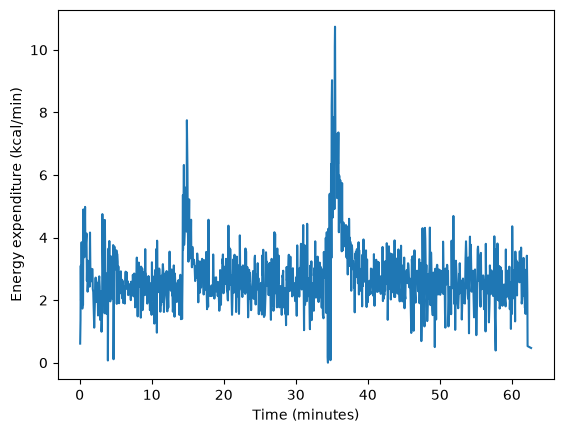

In [89]:
plt.plot(time_seconds / 60, energy_rate)
plt.xlabel("Time (minutes)")
plt.ylabel("Energy expenditure (kcal/min)")
plt.show()

In [90]:
import re
import os

In [98]:
path = os.getcwd().strip("wearable-mlee")
repo_root = path.split("wearable-mlee", 1)[0] + "wearable-mlee"
exg_dir = os.path.join(repo_root, "data\\01_raw\\EXG")

In [100]:
exg_dir
os.listdir(exg_dir)

['.gitkeep',
 'PV01_V2_EXG_20260903.csv',
 'PV01_V2_EXG_20260903.mat',
 'PV01_V3_EXG_20260907.csv',
 'PV01_V3_EXG_20260907.mat',
 'V1PVAU20260903152920.otb+',
 'V1PVAU20260907113113.otb+']

### Find Corresponding EXG File

In [108]:
dateMatch = cosmedStartTimeStamp.strftime("%Y%m%d")
extension = ".otb+"
visit = 2
matching_files = []

for filename in os.listdir(exg_dir):

    match = re.search(
        rf"{dateMatch}\d{{6}}(?=\D*\.otb\+$)",
        filename,
    )

    if match:
        matching_files.append(filename)

matching_files

['V1PVAU20260903152920.otb+']

In [112]:
if len(matching_files) == 0:
    raise FileNotFoundError(
        f"No EXG file found for date {dateMatch}"
    )

if len(matching_files) > 1:
    raise ValueError(
        f"Expected one EXG file for {dateMatch},\
        but found {len(matching_files)}: {matching_files}"
        )

matching_file = matching_files[0]

match = re.search(
    r"(\d{14})(?=\D*\.otb\+$)",
    matching_file,
)

if match is None:
    raise ValueError(f"No timestamp found in {matching_file}")

exgDateTime = datetime.strptime(
    match.group(1),
    "%Y%m%d%H%M%S",
)

In [188]:
matching_file

'V1PVAU20260903152920.otb+'

In [33]:
from datetime import datetime

exgDateTime = datetime.strptime(exgDateTime, "%Y%m%d%H%M%S")

In [113]:
exgDateTime

datetime.datetime(2026, 9, 3, 15, 29, 20)

In [179]:
df_exg = pd.DataFrame(data={"Time [s]": participant_data["devices"]["exg"][2]['Time'][0][0].reshape(-1, ),
                       "EMG [mV]": participant_data["devices"]["exg"][2]["Data"][0, 0][:, 0].reshape(-1, ),
                       "ECG [mV]": participant_data["devices"]["exg"][2]["Data"][0, 0][:, 1].reshape(-1, )})

In [180]:
df_exg.max()

Time [s]    3816.003906
EMG [mV]       3.663127
ECG [mV]       5.230713
dtype: float64

In [181]:
participant_data["devices"]["exg"][2]['Time'][0][0]

array([[0.00000000e+00],
       [4.88281250e-04],
       [9.76562500e-04],
       ...,
       [3.81600293e+03],
       [3.81600342e+03],
       [3.81600391e+03]], shape=(7815177, 1))

In [182]:
participant_data["devices"]["exg"][2]["Data"][0, 0][:, 0].shape

(7815177,)

In [183]:
participant_data["devices"]["exg"][2]['Data'][0]

array([array([[ 0.4597982 , -0.03662109],
              [ 0.289917  , -0.02543131],
              [ 0.26194254, -0.02288818],
              ...,
              [ 0.41249594, -0.07273356],
              [ 0.43436685, -0.06561279],
              [ 0.46437582, -0.06917318]], shape=(7815177, 2), dtype=float32)],
      dtype=object)

In [184]:
# Create absolute timestamps for EXG samples
df_exg["timestamp"] = (
    pd.Timestamp(exgDateTime)
    + pd.to_timedelta(df_exg["Time [s]"], unit="s")
)

# Use absolute EMG amplitude as the activity measure
emg_signal = pd.to_numeric(df_exg["EMG [mV]"], errors="coerce")
emg_activity = emg_signal.abs()

# Smooth the activity envelope
envelope = emg_activity.rolling(
    window=100,
    center=True,
    min_periods=1,
).mean()

# Estimate a noise threshold robustly
baseline = envelope.quantile(0.25)
mad = (envelope - baseline).abs().median()
activity_threshold = baseline + 10 * mad

# Detect the first active point after at least one second of quiet
quiet_before = (
    envelope.shift(1)
    .rolling(1)
    .max()
    < activity_threshold
)

active = envelope >= activity_threshold
onset = active & quiet_before

onset_times = df_exg.loc[onset, "timestamp"]
onset_values = df_exg.loc[onset, "EMG [mV]"]

print(f"Detected {len(onset_times)} EMG onsets")

Detected 5522 EMG onsets


In [185]:
df_exg = df_exg.sort_values("timestamp").set_index("timestamp")

emg_signal = pd.to_numeric(df_exg["EMG [mV]"], errors="coerce")
emg_activity = emg_signal.abs()

envelope = emg_activity.rolling("100ms", min_periods=1).mean()

baseline = envelope.quantile(0.25)
mad = (envelope - baseline).abs().median()
activity_threshold = baseline + 10 * mad

quiet_before = (
    envelope.shift(1).rolling("1s").max()
    < activity_threshold
)

onset = (envelope >= activity_threshold) & quiet_before
onset_times = df_exg.index[onset]

C:\Users\ngz4773\AppData\Local\Temp\ipykernel_460\3480716920.py:64: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


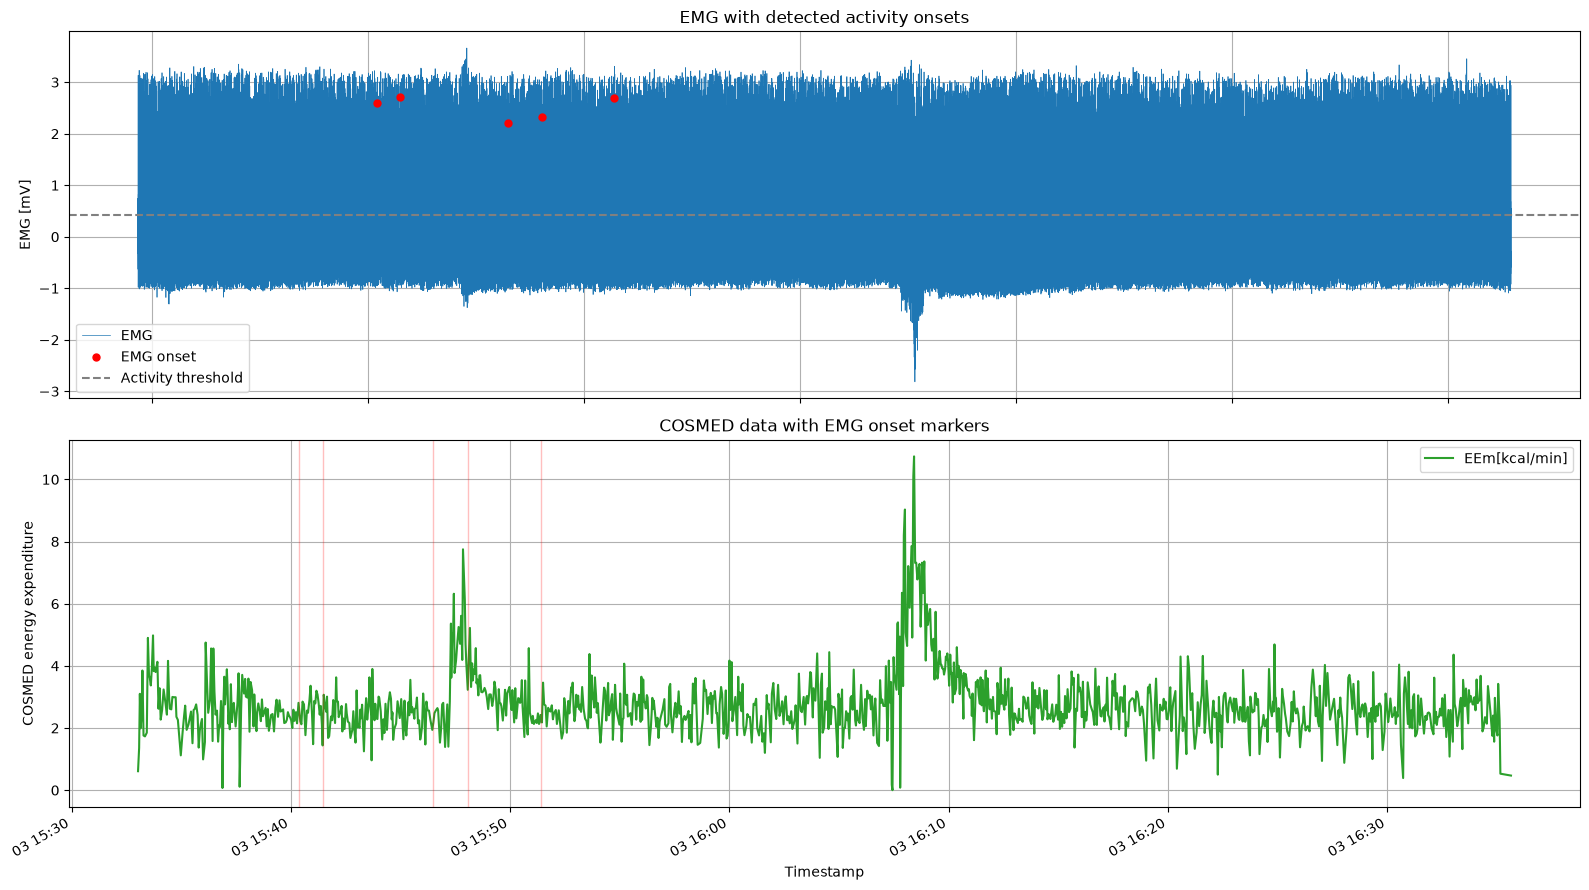

In [186]:
cosmed_column = next(
    column for column in df_cosmed.columns
    if str(column).startswith("EEm")
)

fig, axes = plt.subplots(
    2,
    1,
    figsize=(16, 9),
    sharex=False,
)

# EMG
axes[0].plot(
    df_exg.index,
    df_exg["EMG [mV]"],
    linewidth=0.5,
    label="EMG",
)

axes[0].plot(
    onset_times,
    df_exg.loc[onset_times, "EMG [mV]"],
    "ro",
    markersize=5,
    label="EMG onset",
)

axes[0].axhline(
    activity_threshold,
    color="gray",
    linestyle="--",
    label="Activity threshold",
)

axes[0].set_title("EMG with detected activity onsets")
axes[0].set_ylabel("EMG [mV]")
axes[0].legend()
axes[0].grid(True)

# COSMED
axes[1].plot(
    df_cosmed["timestamp"],
    pd.to_numeric(df_cosmed[cosmed_column], errors="coerce"),
    color="tab:green",
    label=cosmed_column,
)

for onset_time in onset_times:
    axes[1].axvline(
        onset_time,
        color="red",
        alpha=0.25,
        linewidth=1,
    )

axes[1].set_title("COSMED data with EMG onset markers")
axes[1].set_xlabel("Timestamp")
axes[1].set_ylabel("COSMED energy expenditure")
axes[1].legend()
axes[1].grid(True)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [213]:
psd_path = "C:\\Users\\ngz4773\\Downloads\\PV01_V2_EMG_PSD.csv"
psd = pd.read_csv(psd_path, delimiter=";", skiprows=1)

In [214]:
psd.head()

,Frequency [Hz],mV(^2) / Hz,Unnamed: 2
0,0,2.424284e-05,NaN
1,2,2.592113e-06,NaN
2,4,1.409489e-06,NaN
3,6,9.253829e-07,NaN
4,8,1.578378e-06,NaN


In [217]:
psd.drop(psd.columns[2], axis='columns', inplace=True)

In [221]:
psd.head()

,Frequency [Hz],mV(^2) / Hz
0,0,2.424284e-05
1,2,2.592113e-06
2,4,1.409489e-06
3,6,9.253829e-07
4,8,1.578378e-06


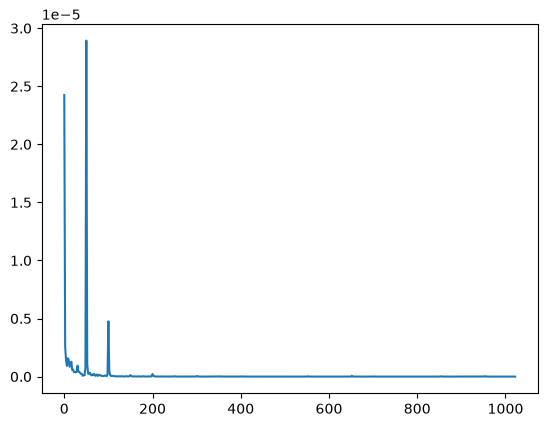

In [222]:
plt.plot(psd["Frequency [Hz]"], psd["mV(^2) / Hz"])

In [239]:
psd[psd["mV(^2) / Hz"] > psd["mV(^2) / Hz"].mean() + 1.5*psd["mV(^2) / Hz"].std()]

,Frequency [Hz],mV(^2) / Hz
0,0,0.000024
25,50,0.000029
50,100,0.000005


In [233]:
psd["mV(^2) / Hz"].max()

np.float64(2.89344024402546e-05)

In [234]:
psd["mV(^2) / Hz"].std()

np.float64(1.6886993507882412e-06)